In [15]:
# Third-Party Library
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from scipy.sparse import load_npz
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [3]:
# Load train data
X_train = load_npz('../data/features/tfidf/X_train.npz')

df_train = pd.read_csv('../data/processed/train_metadata.csv')

print("TF-IDF Train Shape:", X_train.shape)
print("Metadata Train Shape:", df_train.shape)

print("\nAlignment valid:", X_train.shape[0] == len(df_train))

df_train.head()

TF-IDF Train Shape: (35000, 10000)
Metadata Train Shape: (35000, 2)

Alignment valid: True


,id_data,sentiment_label
0,27510,positive
1,34630,positive
2,15278,positive
3,1063,negative
4,38940,positive


In [ ]:
# Load TF-IDF vectorizer

vectorizer = joblib.load(
    '../data/features/tfidf/vectorizer.pkl'
)

feature_names = vectorizer.get_feature_names_out()

print("Vocabulary size:", len(feature_names))
print("Feature count:", X_train.shape[1])

Vocabulary size: 10000
Feature count: 10000


In [10]:
# Prepare target labels

y_train = df_train['sentiment_label']

print("Training label distribution:")
print(y_train.value_counts())

print("\nAlignment valid:", X_train.shape[0] == len(y_train))

Training label distribution:
sentiment_label
positive    17500
negative    17500
Name: count, dtype: int64

Alignment valid: True


In [11]:
# Train SVM Classifier

svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(
    X_train,
    y_train
)

print("SVM training completed.")

SVM training completed.


In [12]:
# Predict training data

train_predictions = svm_model.predict(X_train)

print("Training predictions:", len(train_predictions))

Training predictions: 35000


In [16]:
# Training Evaluation

train_accuracy = accuracy_score(
    y_train,
    train_predictions
)

train_precision = precision_score(
    y_train,
    train_predictions,
    average='weighted'
)

train_recall = recall_score(
    y_train,
    train_predictions,
    average='weighted'
)

train_f1 = f1_score(
    y_train,
    train_predictions,
    average='weighted'
)

print(f"Accuracy : {train_accuracy:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall   : {train_recall:.4f}")
print(f"F1-score : {train_f1:.4f}")

Accuracy : 0.9636
Precision: 0.9636
Recall   : 0.9636
F1-score : 0.9636


# Audit Classification Results

              precision    recall  f1-score   support

    negative       0.97      0.96      0.96     17500
    positive       0.96      0.97      0.96     17500

    accuracy                           0.96     35000
   macro avg       0.96      0.96      0.96     35000
weighted avg       0.96      0.96      0.96     35000



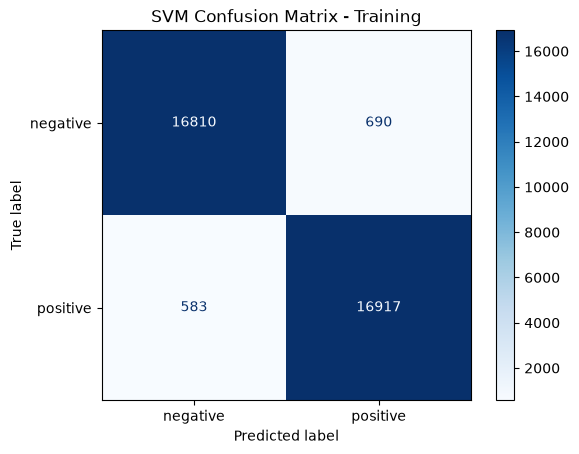

In [17]:
print(classification_report(y_train, train_predictions))

cm_train = confusion_matrix(
    y_train,
    train_predictions,
    labels=svm_model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_train,
    display_labels=svm_model.classes_
)

disp.plot(cmap='Blues')
plt.title('SVM Confusion Matrix - Training')
plt.show()

# Predict Test Data

In [18]:
# Load test data
X_test = load_npz('../data/features/tfidf/X_test.npz')
df_test = pd.read_csv('../data/processed/test_metadata.csv')

print("TF-IDF Test Shape:", X_test.shape)
print("Metadata Test Shape:", df_test.shape)
print("\nAlignment valid:", X_test.shape[0] == len(df_test))

df_test.head()

TF-IDF Test Shape: (15000, 10000)
Metadata Test Shape: (15000, 2)

Alignment valid: True


,id_data,sentiment_label
0,48579,negative
1,36664,negative
2,25641,negative
3,34656,negative
4,11723,negative


In [19]:
# Predict test data
y_test = df_test['sentiment_label']

test_predictions = svm_model.predict(X_test)

print("Test samples :", X_test.shape[0])
print("Predictions  :", len(test_predictions))

Test samples : 15000
Predictions  : 15000


# Test Evaluation

In [20]:
# Test Evaluation
test_accuracy = accuracy_score(y_test, test_predictions)

test_precision = precision_score(
    y_test,
    test_predictions,
    average='weighted'
)

test_recall = recall_score(
    y_test,
    test_predictions,
    average='weighted'
)

test_f1 = f1_score(
    y_test,
    test_predictions,
    average='weighted'
)

print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")

Accuracy : 0.8842
Precision: 0.8842
Recall   : 0.8842
F1-score : 0.8842


# Audit Classification Results

              precision    recall  f1-score   support

    negative       0.89      0.88      0.88      7500
    positive       0.88      0.89      0.88      7500

    accuracy                           0.88     15000
   macro avg       0.88      0.88      0.88     15000
weighted avg       0.88      0.88      0.88     15000



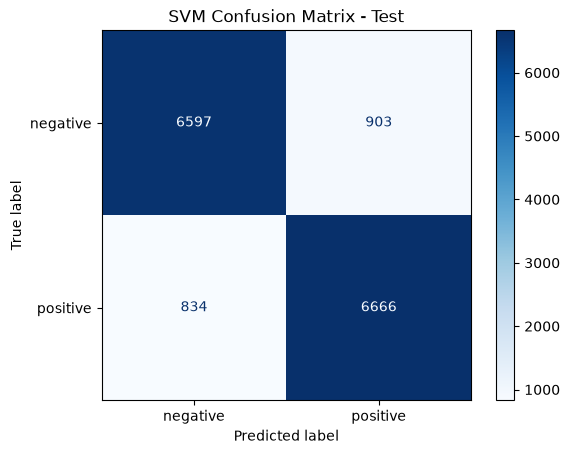

In [21]:
# Classification Report - Test

print(classification_report(y_test, test_predictions))

cm_test = confusion_matrix(
    y_test,
    test_predictions,
    labels=svm_model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=svm_model.classes_
)

disp.plot(cmap='Blues')
plt.title('SVM Confusion Matrix - Test')
plt.show()

# Summary of Classification Performance

In [24]:
# Final Classification Evaluation
final_classification_evaluation = pd.DataFrame({
    'Metric': [
        'Train Samples',
        'Test Samples',
        'Train Accuracy',
        'Test Accuracy',
        'Train Precision',
        'Test Precision',
        'Train Recall',
        'Test Recall',
        'Train F1-score',
        'Test F1-score'
    ],
    'Value': [
        X_train.shape[0],
        X_test.shape[0],
        train_accuracy,
        test_accuracy,
        train_precision,
        test_precision,
        train_recall,
        test_recall,
        train_f1,
        test_f1
    ]
})

display(
    final_classification_evaluation.style.format({
        'Value': '{:.4f}'
    })
)

,Metric,Value
0,Train Samples,35000.0000
1,Test Samples,15000.0000
2,Train Accuracy,0.9636
3,Test Accuracy,0.8842
4,Train Precision,0.9636
5,Test Precision,0.8842
6,Train Recall,0.9636
7,Test Recall,0.8842
8,Train F1-score,0.9636
9,Test F1-score,0.8842
